## imports

In [21]:
# shout out rayd3stroyr hahahaha

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import magic
from matplotlib.path import Path

sc.settings.verbosity = 3
plt.rcParams['pdf.fonttype'] = 42

### data

In [2]:
fbs1 = sc.read_h5ad("/u/project/cluo/mbaig/cosmx/analyses/20240628-brain-6K-test1-analysis/processed_data/MBbrain6Ktest1slide1_adata1_normalized.h5ad")

In [3]:
bgs4 = sc.read_h5ad("/u/project/cluo/mbaig/cosmx/analyses/20250527_MB_basal_2/processed_data/20250527/MBbrain6Kbasalslide4redo_unfiltered_normalized1.h5ad")

In [4]:
# gene list
smoothie = [
    "NKX2-1", "ASCL1", "NR2F2",
    "GAD1", "PROX1",
    "DCX", "SOX11", "MARCKSL1",
    "GFAP", "AQP4", "CLU",
    "MKI67", "TOP2A",
]

## ge plot + quantification

### bgs4 striatal split

In [5]:
spatial_coords_bgs4 = bgs4.obsm['spatial']

# Define initial BGS4 region polygon
polygon_coords_bgs4_initial = np.array([
    [5400, 14000],
    [5100, 12000],
    [5000, 11000],
    [5000, 10000],
    [5300, 8000],
    [5500, 7000],
    [5000, 6000],
    [5000, 5000],
    [7200, 1800],
    [8000, 6000],
    [8000, 6500],
    [8300, 8000],
    [9000, 9000],
    [10100, 11000],
    [9800, 13500]
])

# Create mask for initial BGS4 region
polygon_path_bgs4_initial = Path(polygon_coords_bgs4_initial)
inside_polygon_bgs4_initial = polygon_path_bgs4_initial.contains_points(spatial_coords_bgs4)

# Create initial subset
bgs4_initial = bgs4[inside_polygon_bgs4_initial, :].copy()

# defining LGE/MGE inside bgs4 initial
spatial_coords_bgs4 = bgs4_initial.obsm['spatial']

polygon_coords_bgs4_lge = np.array([
    [6000, 4000],
    [7000, 5000],
    [7500, 5500],
    [7500, 7000],
    [7900, 7900],
    [8500, 8700],
    [9000, 9800],
    [9400, 11000],
    [8500, 14000],
    [11000, 14000],
    [11000, 1800],
    [6000, 1800]
])

polygon_path_lge = Path(polygon_coords_bgs4_lge)
inside_polygon_lge = polygon_path_lge.contains_points(spatial_coords_bgs4)

lge_cells = bgs4_initial[inside_polygon_lge, :].copy()

# Apply MAGIC smoothing to LGE
present_lge = [g for g in smoothie if g in lge_cells.var_names]

magic_operator_lge = magic.MAGIC(knn=5, t=1, solver='approximate')
lge_smooth = magic_operator_lge.fit_transform(lge_cells, genes=present_lge)

lge_cells2 = lge_smooth

Calculating MAGIC...
  Running MAGIC on 25511 cells and 6175 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 8.98 seconds.
    Calculating KNN search...
    Calculated KNN search in 5.22 seconds.
    Calculating affinities...
    Calculated affinities in 7.96 seconds.
  Calculated graph and diffusion operator in 22.21 seconds.
  Calculating imputation...
  Calculated imputation in 0.01 seconds.
Calculated MAGIC in 22.31 seconds.


In [6]:
# define MGE (NKX2-1) and LGE (ASCL1)
nkx21_expr = lge_cells2[:, 'NKX2-1'].X.toarray().flatten() if hasattr(lge_cells2.X, 'toarray') else lge_cells2[:, 'NKX2-1'].X.flatten()
ascl1_expr = lge_cells2[:, 'ASCL1'].X.toarray().flatten() if hasattr(lge_cells2.X, 'toarray') else lge_cells2[:, 'ASCL1'].X.flatten()

nkx21_pop = (nkx21_expr > 0.15) & (nkx21_expr > ascl1_expr)
ascl1_pop = (ascl1_expr > 0.15) & (ascl1_expr > nkx21_expr)
other = ~nkx21_pop & ~ascl1_pop

lge_cells2.obs['nkx_ascl_cluster'] = 'Other'
lge_cells2.obs.loc[nkx21_pop, 'nkx_ascl_cluster'] = 'NKX2-1_high'
lge_cells2.obs.loc[ascl1_pop, 'nkx_ascl_cluster'] = 'ASCL1_high'
lge_cells2.obs['nkx_ascl_cluster'] = lge_cells2.obs['nkx_ascl_cluster'].astype('category')

### fbs1 cge

In [7]:
spatial_coords_fbs1 = fbs1.obsm['spatial']

polygon_coords_fbs1_rec = np.array([
    [3900, 7500],
    [4700, 4900],
    [5000, 4700],
    [5100, 2500],
    [5150, 1000],
    [4900, -510],
    [11000, -510],
    [11000, 7500]
])

polygon_path_fbs1_rec = Path(polygon_coords_fbs1_rec)
inside_polygon_fbs1_rec = polygon_path_fbs1_rec.contains_points(spatial_coords_fbs1)

# Create FBS1 REC subset
fbs1_rec = fbs1[inside_polygon_fbs1_rec, :].copy()

# Apply MAGIC smoothing to FBS1 REC subset
present_fbs1_genes = [g for g in smoothie if g in fbs1_rec.var_names]

magic_operator_fbs1 = magic.MAGIC(knn=5, t=1, solver='approximate')
fbs1_rec_smooth = magic_operator_fbs1.fit_transform(fbs1_rec, genes=present_fbs1_genes)

# Convert back to AnnData
fbs1_rec_smooth2 = fbs1_rec_smooth

Calculating MAGIC...
  Running MAGIC on 148593 cells and 6175 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 91.03 seconds.
    Calculating KNN search...
    Calculated KNN search in 162.48 seconds.
    Calculating affinities...
    Calculated affinities in 135.65 seconds.
  Calculated graph and diffusion operator in 389.59 seconds.
  Calculating imputation...
  Calculated imputation in 0.12 seconds.
Calculated MAGIC in 390.46 seconds.


In [8]:
# CGE (NR2F2)
nr2f2_expr_all = fbs1_rec_smooth2[:, 'NR2F2'].X.toarray().flatten() if hasattr(fbs1_rec_smooth2.X, 'toarray') else fbs1_rec_smooth2[:, 'NR2F2'].X.flatten()
cge_cells = fbs1_rec_smooth2[nr2f2_expr_all > 0.15].copy()


fbs1_rec_smooth2.obsm['spatial'] = fbs1_rec.obsm['spatial'].copy()

# Copy spatial coordinates to cge_cells
cge_cells.obsm['spatial'] = fbs1_rec_smooth2[nr2f2_expr_all > 0.15].obsm['spatial'].copy()

polygon_coords = np.array([
    [3900, 7500],
    [4700, 4900],
    [5000, 4700],
    [5100, 2500],
    [5150, 1000],
    [4900, -510],
    [7000, -510],
    [7000, 7500]
])

polygon_path_cge = Path(polygon_coords)

coords_cge = cge_cells.obsm['spatial']
coords_fbs1 = fbs1_rec_smooth2.obsm['spatial']

inside_polygon_cge = polygon_path_cge.contains_points(coords_cge)

cge_cells = cge_cells[inside_polygon_cge, :].copy()

### data prep + plot

In [9]:
# BGS4 data (using smoothed lge_cells2)
present_bgs4 = [g for g in smoothie if g in lge_cells2.var_names]
data_list_bgs4 = []
for gene in present_bgs4:
    expr = lge_cells2[:, gene].X.toarray().flatten() if hasattr(lge_cells2.X, 'toarray') else lge_cells2[:, gene].X.flatten()
    cluster = lge_cells2.obs['nkx_ascl_cluster'].values
    
    for e, c in zip(expr, cluster):
        if c in ['NKX2-1_high', 'ASCL1_high']:
            data_list_bgs4.append({'Gene': gene, 'Expression': e, 'Cluster': c, 'Tissue': 'BGS4'})

# CGE data (only from cge_cells subset)
present_cge = [g for g in smoothie if g in cge_cells.var_names]
data_list_cge = []
for gene in present_cge:
    expr = cge_cells[:, gene].X.toarray().flatten() if hasattr(cge_cells.X, 'toarray') else cge_cells[:, gene].X.flatten()
    
    for e in expr:
        data_list_cge.append({'Gene': gene, 'Expression': e, 'Cluster': 'NR2F2_high', 'Tissue': 'CGE'})

# Combine all data
all_data = data_list_bgs4 + data_list_cge
df_all = pd.DataFrame(all_data)

# Find genes present in both datasets
all_markers = [g for g in smoothie if g in present_bgs4 and g in present_cge]
df_all = df_all[df_all['Gene'].isin(all_markers)]

/tmp/ipykernel_31087/2599930383.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_31087/2599930383.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


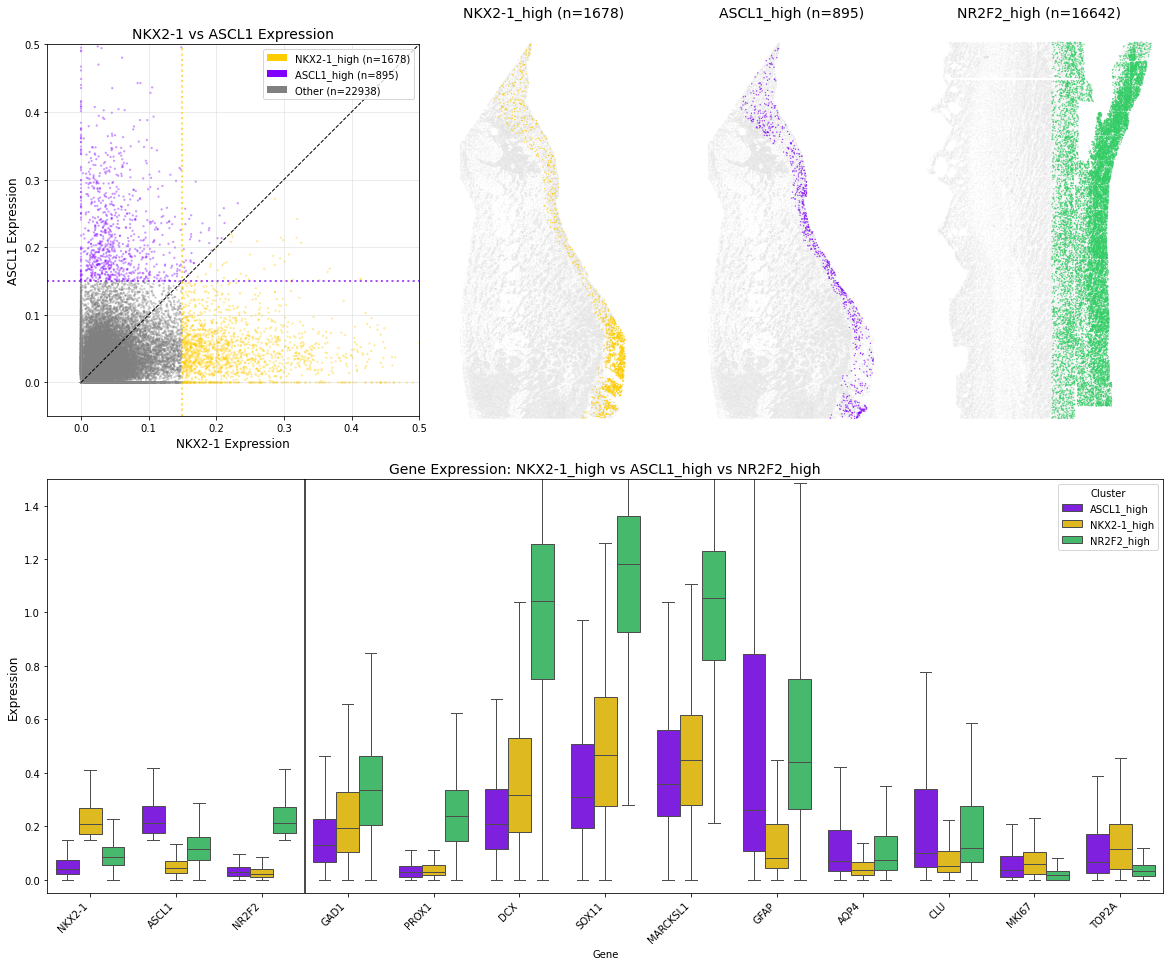

In [10]:
# plot parameters
from matplotlib.patches import Patch
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1], width_ratios=[0.6, 0.4, 0.4, 0.4], 
                      wspace=0, hspace=0.1)

coords_bgs4 = bgs4_initial.obsm['spatial']
coords_lge = lge_cells.obsm['spatial']
coords_cge = cge_cells.obsm['spatial']

# colors
blaze_orange = np.array([1.00, 0.80, 0.00])
blue_violet = np.array([0.50, 0.00, 1.00])
green = np.array([0.2, 0.8, 0.4])

# # # TOP ROW
### Panel 1: XY scatter (NKX2-1 vs ASCL1)
ax0 = fig.add_subplot(gs[0, 0])

np.random.seed(42)
plot_order = np.random.permutation(len(nkx21_expr))

colors = np.ones((len(nkx21_expr), 3)) * 0.5
colors[nkx21_pop] = blaze_orange
colors[ascl1_pop] = blue_violet

ax0.scatter(nkx21_expr[plot_order], ascl1_expr[plot_order], 
           s=5, alpha=0.4, c=colors[plot_order], edgecolors='none', rasterized=True)

max_val = 0.5
ax0.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='NKX2-1 = ASCL1')
ax0.axvline(0.15, color=tuple(blaze_orange), linestyle=':', linewidth=2, alpha=0.7)
ax0.axhline(0.15, color=tuple(blue_violet), linestyle=':', linewidth=2, alpha=0.7)

ax0.set_xlabel('NKX2-1 Expression', fontsize=12)
ax0.set_ylabel('ASCL1 Expression', fontsize=12)
ax0.set_title('NKX2-1 vs ASCL1 Expression', fontsize=14)
ax0.set_xlim(-0.05, max_val)
ax0.set_ylim(-0.05, max_val)
ax0.grid(True, alpha=0.3)
ax0.set_aspect('equal')

legend_elements = [
    Patch(facecolor=blaze_orange, label=f'NKX2-1_high (n={nkx21_pop.sum()})'),
    Patch(facecolor=blue_violet, label=f'ASCL1_high (n={ascl1_pop.sum()})'),
    Patch(facecolor=[0.5, 0.5, 0.5], label=f'Other (n={other.sum()})')
]
ax0.legend(handles=legend_elements, loc='upper right')

### Panel 2: NKX2-1 spatial
ax1 = fig.add_subplot(gs[0, 1])
nkx_indices = np.where(nkx21_pop)[0]
ax1.scatter(coords_bgs4[:, 0], coords_bgs4[:, 1], c='lightgray', s=0.5, alpha=0.3, edgecolors='none', rasterized=True)
ax1.scatter(coords_lge[nkx_indices, 0], coords_lge[nkx_indices, 1], 
           c=[blaze_orange], s=2, alpha=0.7, edgecolors='none', rasterized=True)
ax1.invert_yaxis()
ax1.set_aspect('equal')
ax1.set_title(f'NKX2-1_high (n={nkx21_pop.sum()})', fontsize=14)
ax1.set_axis_off()

### Panel 3: ASCL1 spatial
ax2 = fig.add_subplot(gs[0, 2])
ascl1_indices = np.where(ascl1_pop)[0]
ax2.scatter(coords_bgs4[:, 0], coords_bgs4[:, 1], c='lightgray', s=0.5, alpha=0.3, edgecolors='none', rasterized=True)
ax2.scatter(coords_lge[ascl1_indices, 0], coords_lge[ascl1_indices, 1], 
           c=[blue_violet], s=2, alpha=0.7, edgecolors='none', rasterized=True)
ax2.invert_yaxis()
ax2.set_aspect('equal')
ax2.set_title(f'ASCL1_high (n={ascl1_pop.sum()})', fontsize=14)
ax2.set_axis_off()

### Panel 4: NR2F2 spatial
ax3 = fig.add_subplot(gs[0, 3])
ax3.scatter(fbs1_rec.obsm['spatial'][:, 0], fbs1_rec.obsm['spatial'][:, 1], 
           c='lightgray', s=0.5, alpha=0.3, edgecolors='none', rasterized=True)

# Show CGE cells in green
ax3.scatter(coords_cge[:, 0], coords_cge[:, 1], 
           c=[green], s=2, alpha=0.7, edgecolors='none', rasterized=True)

ax3.invert_xaxis()
ax3.set_title(f'NR2F2_high (n={cge_cells.n_obs})', fontsize=14)
ax3.set_axis_off()

# # # BOTTOM ROW - Combined Boxplot spanning all 4 columns
ax4 = fig.add_subplot(gs[1, :])

sns.boxplot(data=df_all, x='Gene', y='Expression', hue='Cluster',
            palette={'NKX2-1_high': blaze_orange, 'ASCL1_high': blue_violet, 'NR2F2_high': green},
            ax=ax4, showfliers=False)

ax4.axvline(x=2.5, color='black', linestyle='-', linewidth=2, alpha=0.7)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.set_ylabel('Expression', fontsize=12)
ax4.set_title('Gene Expression: NKX2-1_high vs ASCL1_high vs NR2F2_high', fontsize=14)
ax4.legend(title='Cluster')
ax4.set_ylim(-0.05, 1.5)

plt.tight_layout()
#plt.savefig('nkx21_ascl1_nr2f2_figure.pdf', 
#            format='pdf', 
#            dpi=300, 
#            bbox_inches='tight',
#            facecolor='white')
plt.show()

## magic gene smoothing

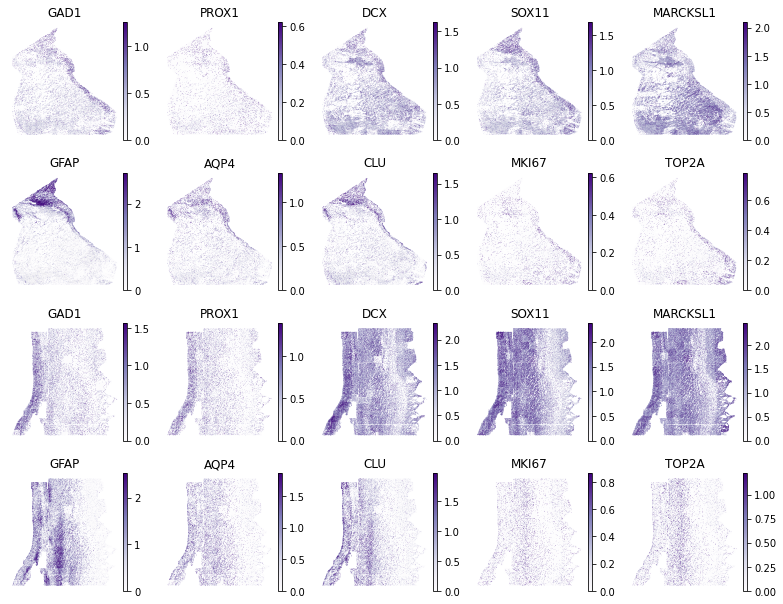

In [17]:
smoothie_rest = smoothie[3:]

fig, axes = plt.subplots(4, 5, figsize=(11, 8.5))

# Flatten axes for easier indexing
axes = axes.flatten()

# First 2 rows (0-9): BGS4
for i, gene in enumerate(smoothie_rest):
    sc.pl.embedding(bgs4_initial, basis='spatial', color=gene, 
                    ax=axes[i], show=False, size=0.5, vmax='p99', cmap='Purples')
    axes[i].invert_yaxis()
    axes[i].set_title(f'{gene}', fontsize=12)
    axes[i].axis('off')
    for collection in axes[i].collections:
        collection.set_rasterized(True)

# Last 2 rows (10-19): FBS1
for i, gene in enumerate(smoothie_rest):
    sc.pl.embedding(fbs1_rec, basis='spatial', color=gene, 
                    ax=axes[i+10], show=False, size=0.5, vmax='p99', cmap='Purples')
    axes[i+10].invert_yaxis()
    axes[i+10].set_title(f'{gene}', fontsize=12)
    axes[i+10].axis('off')
    for collection in axes[i+10].collections:
        collection.set_rasterized(True)

plt.tight_layout()
#plt.savefig('gene_expression_grid_unsmoothed.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

## fbs1 composite

In [24]:
# additional genes for regionalisation
smoothie = [
    "NKX2-1", "ASCL1", "NR2F2", "PROX1",
    "LHX6", "SP8", "GAD1",
    "GFAP", "AQP4",
    "CLU", "TH",
    "DCX", "SOX11", "MARCKSL1", "TUBB3",
    "MKI67", "TOP2A",
    "VIM", "RBFOX3"
]

# Check which genes are present
present_fbs1 = [g for g in smoothie if g in fbs1_rec.var_names]

# FBS1
magic_operator_fbs1 = magic.MAGIC(knn=5, t=1, solver='approximate')
fbs1_rec_smooth2 = magic_operator_fbs1.fit_transform(fbs1_rec, genes=present_fbs1)
fbs1_rec_smooth2.obsm['spatial'] = fbs1_rec.obsm['spatial'].copy()

Calculating MAGIC...
  Running MAGIC on 148593 cells and 6175 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 97.60 seconds.
    Calculating KNN search...
    Calculated KNN search in 150.07 seconds.
    Calculating affinities...
    Calculated affinities in 122.21 seconds.
  Calculated graph and diffusion operator in 370.24 seconds.
  Calculating imputation...
  Calculated imputation in 0.13 seconds.
Calculated MAGIC in 371.45 seconds.


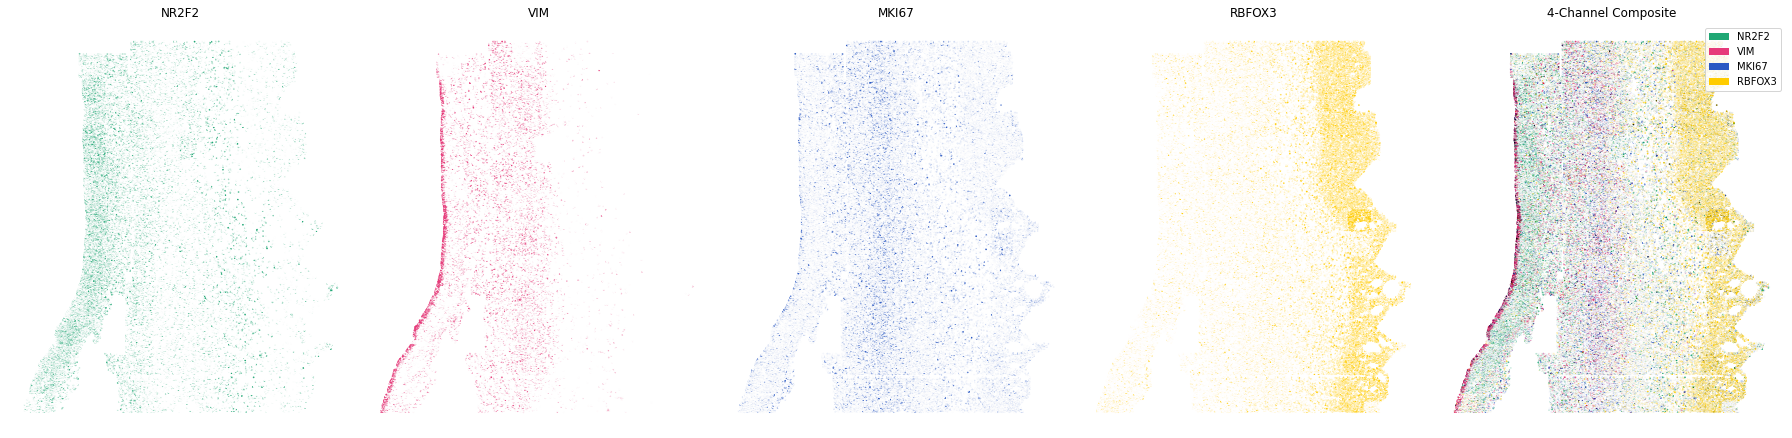

In [25]:
import scipy.sparse
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 5, figsize=(25, 8))

# Get expression values for all four genes from fbs1_rec_smooth2
nr2f2_expr = fbs1_rec_smooth2[:, 'NR2F2'].X
vim_expr = fbs1_rec_smooth2[:, 'VIM'].X
mki67_expr = fbs1_rec_smooth2[:, 'MKI67'].X
rbfox3_expr = fbs1_rec_smooth2[:, 'RBFOX3'].X

# Handle sparse matrices and flatten
genes_expr = []
for expr in [nr2f2_expr, vim_expr, mki67_expr, rbfox3_expr]:
    if scipy.sparse.issparse(expr):
        genes_expr.append(expr.toarray().flatten())
    else:
        genes_expr.append(expr.flatten())

nr2f2_expr, vim_expr, mki67_expr, rbfox3_expr = genes_expr

# Calculate percentile thresholds and normalize
nr2f2_min, nr2f2_max = np.percentile(nr2f2_expr, [80, 99])
vim_min, vim_max = np.percentile(vim_expr, [90, 99])
mki67_min, mki67_max = np.percentile(mki67_expr, [50, 99])
rbfox3_min, rbfox3_max = np.percentile(rbfox3_expr, [60, 99])

nr2f2_norm = np.clip((nr2f2_expr - nr2f2_min) / (nr2f2_max - nr2f2_min), 0, 1)
vim_norm = np.clip((vim_expr - vim_min) / (vim_max - vim_min), 0, 1)
mki67_norm = np.clip((mki67_expr - mki67_min) / (mki67_max - mki67_min), 0, 1)
rbfox3_norm = np.clip((rbfox3_expr - rbfox3_min) / (rbfox3_max - rbfox3_min), 0, 1)

coords = fbs1_rec_smooth2.obsm['spatial']


# Define colors
dusk_blue = np.array([0x2b, 0x59, 0xc3]) / 255      # deep cool blue
bubblegum_pink = np.array([0xe6, 0x3b, 0x7a]) / 255 # vivid magenta-pink
royal_gold = np.array([0xff, 0xcc, 0x00]) / 255     # warm saturated gold
emerald = np.array([0x1f, 0xa7, 0x74]) / 255        # rich emerald green


# Panel 1: NR2F2 (emerald)
rgb_nr2f2 = np.ones((len(nr2f2_norm), 3))
for i in range(3):
    rgb_nr2f2[:, i] = 1 - nr2f2_norm * (1 - emerald[i])

axes[0].scatter(coords[:, 0], coords[:, 1], c=rgb_nr2f2, s=3, edgecolors='none', rasterized=True)
axes[0].invert_yaxis()
axes[0].set_title('NR2F2')
axes[0].set_axis_off()
axes[0].set_aspect('equal')

# Panel 2: VIM (bubblegum pink)
rgb_vim = np.ones((len(vim_norm), 3))
for i in range(3):
    rgb_vim[:, i] = 1 - vim_norm * (1 - bubblegum_pink[i])

axes[1].scatter(coords[:, 0], coords[:, 1], c=rgb_vim, s=3, edgecolors='none', rasterized=True)
axes[1].invert_yaxis()
axes[1].set_title('VIM')
axes[1].set_axis_off()
axes[1].set_aspect('equal')

# Panel 3: MKI67 (royal gold)
rgb_mki67 = np.ones((len(mki67_norm), 3))
for i in range(3):
    rgb_mki67[:, i] = 1 - mki67_norm * (1 - dusk_blue[i])

axes[2].scatter(coords[:, 0], coords[:, 1], c=rgb_mki67, s=3, edgecolors='none', rasterized=True)
axes[2].invert_yaxis()
axes[2].set_title('MKI67')
axes[2].set_axis_off()
axes[2].set_aspect('equal')

# Panel 4: RBFOX3 (dusk blue)
rgb_rbfox3 = np.ones((len(rbfox3_norm), 3))
for i in range(3):
    rgb_rbfox3[:, i] = 1 - rbfox3_norm * (1 - royal_gold[i])

axes[3].scatter(coords[:, 0], coords[:, 1], c=rgb_rbfox3, s=3, edgecolors='none', rasterized=True)
axes[3].invert_yaxis()
axes[3].set_title('RBFOX3')
axes[3].set_axis_off()
axes[3].set_aspect('equal')

# Panel 5: Composite of all four
rgb_composite = np.ones((len(nr2f2_norm), 3))
for i in range(3):
    rgb_composite[:, i] = (1 - nr2f2_norm * (1 - emerald[i]) 
                          - vim_norm * (1 - bubblegum_pink[i])
                          - mki67_norm * (1 - dusk_blue[i])
                          - rbfox3_norm * (1 - royal_gold[i]))
    rgb_composite[:, i] = np.clip(rgb_composite[:, i], 0, 1)

axes[4].scatter(coords[:, 0], coords[:, 1], c=rgb_composite, s=3, edgecolors='none', rasterized=True)
axes[4].invert_yaxis()
axes[4].set_title('4-Channel Composite')
axes[4].set_axis_off()
axes[4].set_aspect('equal')

# Add legend
legend_elements = [
    Patch(facecolor=emerald, label='NR2F2'),
    Patch(facecolor=bubblegum_pink, label='VIM'),
    Patch(facecolor=dusk_blue, label='MKI67'),
    Patch(facecolor=royal_gold, label='RBFOX3')
]
axes[4].legend(handles=legend_elements, loc='upper right', frameon=True, facecolor='white')

plt.tight_layout()
#plt.savefig('fbs1_rec_4channel.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

FOV351 width: 507.82 pixels
FOV352 width: 505.06 pixels
Average FOV width: 506.44 pixels = 509.51 µm
2 FOVs = 1012.88 pixels = ~1 mm
Pixels per mm: 993.99


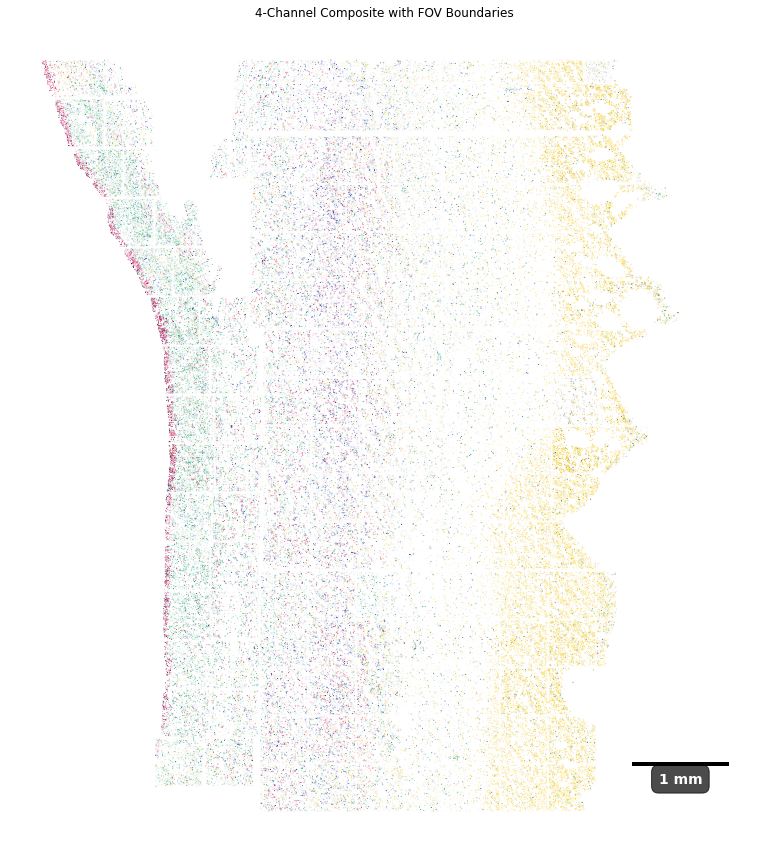

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# Use the spatial coordinates
coords = fbs1_rec_smooth2.obsm['spatial']

# Get FOV information
fovs = fbs1_rec_smooth2.obs['fov'].unique()

fig, ax = plt.subplots(figsize=(12, 12))

# Your plot with spatial coordinates
ax.scatter(coords[:, 0], coords[:, 1], c=rgb_composite, s=1, edgecolors='none', rasterized=True)
ax.set_title('4-Channel Composite with FOV Boundaries')
ax.set_axis_off()
ax.set_aspect('equal')

# Draw FOV boxes (no labels)
for fov in fovs:
    # Get cells in this FOV
    fov_mask = fbs1_rec_smooth2.obs['fov'] == fov
    fov_coords = coords[fov_mask]
    
    if len(fov_coords) == 0:
        continue
    
    # Get bounding box for this FOV
    x_min, x_max = fov_coords[:, 0].min(), fov_coords[:, 0].max()
    y_min, y_max = fov_coords[:, 1].min(), fov_coords[:, 1].max()
    
    # Draw rectangle
    width = x_max - x_min
    height = y_max - y_min
    
    rect = Rectangle((x_min, y_min), width, height, 
                     linewidth=2, edgecolor='white', facecolor='none', 
                     linestyle='--', alpha=0.7)
    ax.add_patch(rect)

# Get FOV351 and FOV352 to calculate scale
fov351_mask = fbs1_rec_smooth2.obs['fov'] == '351'
fov352_mask = fbs1_rec_smooth2.obs['fov'] == '352'

if fov351_mask.sum() > 0 and fov352_mask.sum() > 0:
    fov351_coords = coords[fov351_mask]
    fov352_coords = coords[fov352_mask]
    
    # Calculate width of each FOV in pixel coordinates
    fov351_width = fov351_coords[:, 0].max() - fov351_coords[:, 0].min()
    fov352_width = fov352_coords[:, 0].max() - fov352_coords[:, 0].min()
    
    # Average width in pixels (should be similar)
    avg_fov_width_pixels = (fov351_width + fov352_width) / 2
    
    # Known width: 509.50608 µm per FOV, so 1019.01216 µm for 2 FOVs ≈ 1 mm
    fov_width_um = 509.50608
    two_fov_width_um = 1019.01216
    
    # Calculate pixels per mm
    pixels_per_mm = (2 * avg_fov_width_pixels) / 1.019  # 1.019 mm
    
    print(f"FOV351 width: {fov351_width:.2f} pixels")
    print(f"FOV352 width: {fov352_width:.2f} pixels")
    print(f"Average FOV width: {avg_fov_width_pixels:.2f} pixels = {fov_width_um:.2f} µm")
    print(f"2 FOVs = {2*avg_fov_width_pixels:.2f} pixels = ~1 mm")
    print(f"Pixels per mm: {pixels_per_mm:.2f}")
    
    # Draw 1 mm scale bar as a simple line
    scale_length_pixels = pixels_per_mm  # 1 mm
    
    x_min_all, x_max_all = coords[:, 0].min(), coords[:, 0].max()
    y_min_all, y_max_all = coords[:, 1].min(), coords[:, 1].max()
    
    scale_x = x_max_all - 500  # offset from left
    scale_y = y_min_all + 500  # offset from bottom (remember y is inverted)
    
    # Draw simple horizontal line
    ax.plot([scale_x, scale_x + scale_length_pixels], [scale_y, scale_y], 
            'k-', linewidth=4)
    
    # Add text label
    ax.text(scale_x + scale_length_pixels/2, scale_y - 200, 
            '1 mm', 
            color='white', fontsize=14, ha='center', weight='bold',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.7, pad=0.5))

plt.tight_layout()
#plt.savefig('fbs1_rec_4channel_with_fov.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()